In [98]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [99]:
ias15_2 = pd.read_csv(
    "embryo_ias15_Jul10/famtree_2",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)
ias15_2

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,86.01725,4,31,4,29,8.304772e-07,5.168290e-07,3.913242e-07,0.000034,0.000029,0.000026,1.140499,0.312626
1,86.01725,4,32,4,29,7.767599e-08,5.168290e-07,3.913242e-07,0.000015,0.000029,0.000026,1.140499,0.312626
2,983.20000,2,34,15,8,9.689160e-07,5.352333e-07,4.336826e-07,0.000036,0.000029,0.000027,1.187692,0.949853


In [100]:
coll_1 = ias15_2[ias15_2['parent1_id'] == 4]
t1 = coll_1['t'].iloc[0]

In [101]:
ias15_2_archive = rebound.Simulationarchive("embryo_ias15_Jul10/archive_timestep.bin")

In [102]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [103]:
len(ias15_2_archive)

10681

In [104]:
ias15_2_times = []
ias15_2_n_bodies = []
ias15_2_masses = []
ias15_2_mass_errors = []
ias15_2_angular_momentums = []
ias15_2_L_rel_errors = []
ias15_2_Es = []
ias15_2_E_rel_errors = []
snapshot_idxs = []

for i in range(len(ias15_2_archive)):
    snap = ias15_2_archive[i]
    snapshot_idxs.append(i)
    ias15_2_times.append(snap.t)
    ias15_2_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    ias15_2_angular_momentums.append(get_abs(Lx, Ly, Lz))
    ias15_2_Es.append(snap.energy())

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    ias15_2_masses.append(m)

for i in range(len(ias15_2_masses)):
    diff = np.abs((ias15_2_masses[i] - ias15_2_masses[0]))
    rel_diff = diff/np.abs(ias15_2_masses[0])
    ias15_2_mass_errors.append(rel_diff)

for i in range(len(ias15_2_angular_momentums)):
    diff = np.abs(ias15_2_angular_momentums[i] - ias15_2_angular_momentums[0])
    ias15_2_L_rel_errors.append(diff/np.abs(ias15_2_angular_momentums[0]))

for i in range(len(ias15_2_Es)):
    diff = np.abs(ias15_2_Es[i] - ias15_2_Es[0])
    ias15_2_E_rel_errors.append(diff/np.abs(ias15_2_Es[0]))


ias15_2_dict = {
    't': ias15_2_times,
    'N_Bodies': ias15_2_n_bodies,
    'total_masses': ias15_2_masses,
    'm_errors': ias15_2_mass_errors,
    'angular_momentums': ias15_2_angular_momentums,
    'L_rel_errors': ias15_2_L_rel_errors,
    'E': ias15_2_Es,
    'E_rel_errors': ias15_2_E_rel_errors,
    'snapshot_idx': snapshot_idxs
}

ias15_2_archive_df = pd.DataFrame(ias15_2_dict)

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [105]:
ias15_2_archive_df

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
0,80.000434,31,1.000008,0.0,0.000026,0.000000e+00,-0.000592,0.000000e+00,0
1,80.001348,31,1.000008,0.0,0.000026,5.129527e-16,-0.000592,9.155505e-16,1
2,80.002262,31,1.000008,0.0,0.000026,0.000000e+00,-0.000592,4.394642e-15,2
3,80.003175,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,9.155505e-16,3
4,80.004088,31,1.000008,0.0,0.000026,3.847145e-16,-0.000592,1.831101e-15,4
...,...,...,...,...,...,...,...,...,...
10676,88.942970,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10676
10677,88.943880,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10677
10678,88.944791,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10678
10679,88.945689,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10679


In [106]:
close_up = ias15_2_archive_df[(ias15_2_archive_df['t'] < t1 + 0.001) & (ias15_2_archive_df['t'] > t1 - 0.001)]
close_up

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
7173,86.016317,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,1.647991e-15,7173
7174,86.016549,31,1.000008,0.0,0.000026,3.847145e-16,-0.000592,7.324404e-16,7174
7175,86.016685,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,1.281771e-15,7175
7176,86.016774,31,1.000008,0.0,0.000026,3.847145e-16,-0.000592,7.324404e-16,7176
7177,86.016838,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,3.295982e-15,7177
7178,86.016887,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,9.155505e-16,7178
7179,86.016927,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,2.380431e-15,7179
7180,86.016960,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,1.098661e-15,7180
7181,86.016988,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,3.662202e-16,7181
7182,86.017014,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,5.493303e-16,7182


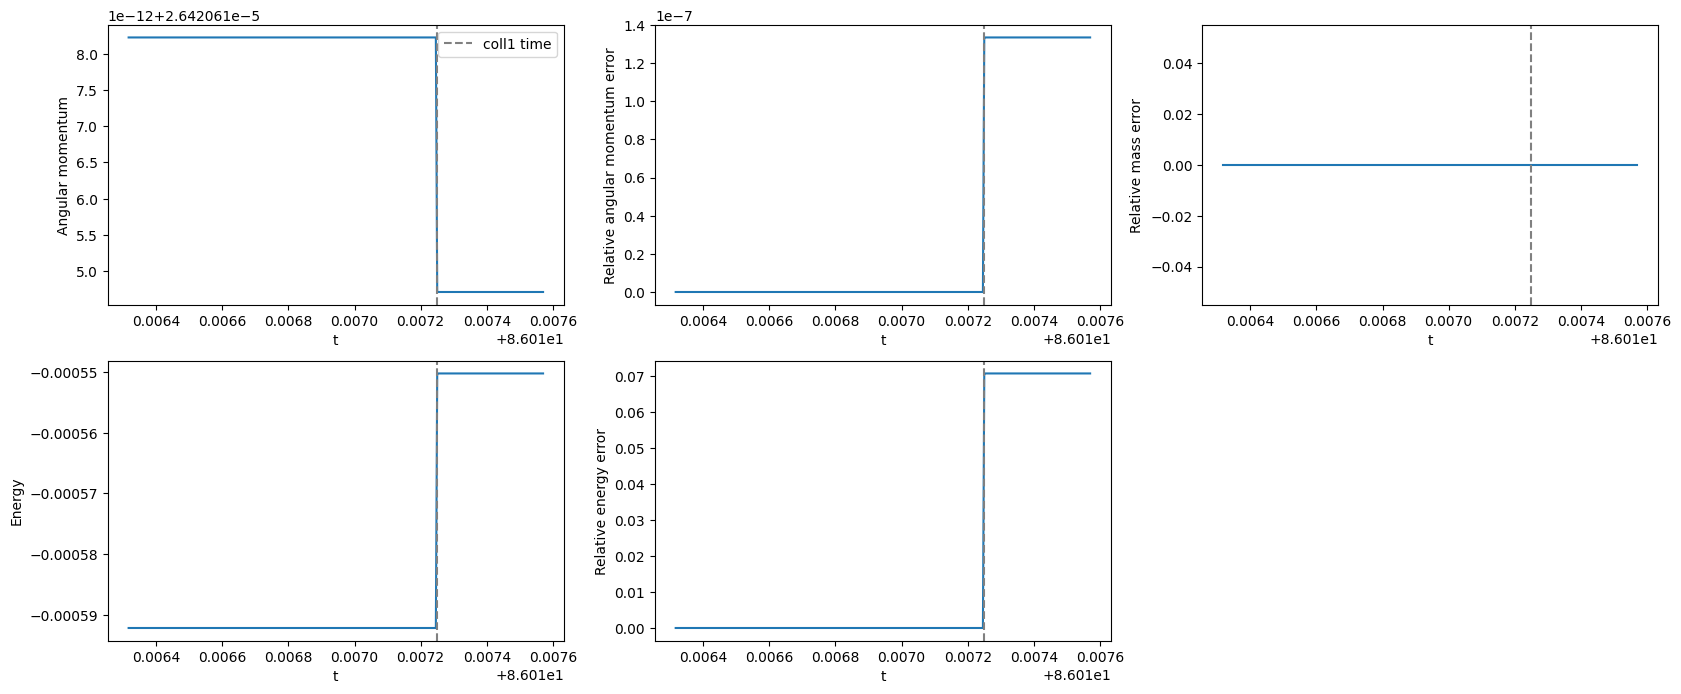

In [107]:
plt.figure(figsize=(20,8))
plt.subplot(2,3,1)
plt.plot(close_up['t'], close_up['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(2,3,2)
plt.plot(close_up['t'], close_up['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,3)
plt.plot(close_up['t'], close_up['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,4)
plt.plot(close_up['t'], close_up['E'])
plt.xlabel('t')
plt.ylabel("Energy")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,5)
plt.plot(close_up['t'], close_up['E_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative energy error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

In [108]:
for i in range(len(ias15_2_archive_df) - 1):
    if (ias15_2_archive_df['L_rel_errors'].iloc[i+1] - ias15_2_archive_df['L_rel_errors'].iloc[i]) > 1e-8:
        idx_before = i
        idx_after = i+1
        print(f"N_bodies before coll = {ias15_2_archive_df['N_Bodies'].iloc[i]}, L error before coll = {ias15_2_archive_df['L_rel_errors'].iloc[i]}")
        print(f"N_bodies after coll = {ias15_2_archive_df['N_Bodies'].iloc[i+1]}, L error after coll = {ias15_2_archive_df['L_rel_errors'].iloc[i+1]}")
        print(f"idx_before = {idx_before}")
        print(f"idx_after = {idx_after}")

N_bodies before coll = 31, L error before coll = 2.5647634429689665e-16
N_bodies after coll = 31, L error after coll = 1.3343607088296344e-07
idx_before = 7201
idx_after = 7202


In [109]:
snap_before = ias15_2_archive[idx_before]
snap_after = ias15_2_archive[idx_after]

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [110]:
# Based on the famtree (collision output) file. Using this mass, we can find the particles right before the collision.

m_parent1_famtree = coll_1['parent1_mass'].iloc[0]
m_parent2_famtree = coll_1['parent2_mass'].iloc[0]
r_parent1_famtree = coll_1['parent1_radius'].iloc[0]
r_parent2_famtree = coll_1['parent2_radius'].iloc[0]

m_frag1_famtree = coll_1['new_mass'].iloc[0]
m_frag2_famtree = coll_1['new_mass'].iloc[1]

print("parent1 mass in famtree = ", m_parent1_famtree)
print("parent2 mass in famtree = ", m_parent2_famtree)

parent1 mass in famtree =  5.16829e-07
parent2 mass in famtree =  3.913242e-07


In [121]:
for i in range(snap_before.N):
    particle = snap_before.particles[i]
    if np.isclose(particle.m, m_parent1_famtree, atol=1e-11):
        parent1_archive = particle
        print(f"parent1 found in archive, mass = {parent1_archive.m}, diff with famtree = {np.abs(m_parent1_famtree - parent1_archive.m)}")

    if np.isclose(particle.m, m_parent2_famtree, atol=1e-11):
        parent2_archive = particle
        print(f"parent2 found in archive, mass = {parent2_archive.m}, diff with famtree = {np.abs(m_parent2_famtree - parent2_archive.m)}")

parent1 found in archive, mass = 5.168289745479957e-07, diff with famtree = 2.5452004294033905e-14
parent2 found in archive, mass = 3.9132422304382745e-07, diff with famtree = 2.3043827473947425e-14


In [125]:
for i in range(snap_after.N):
    particle = snap_after.particles[i]
    if np.isclose(particle.m, m_frag1_famtree, atol=1e-11):
        frag1 = particle
        print(f"frag1 found in archive (lr), mass =  {frag1.m}, diff with famtree = {np.abs(frag1.m - m_frag1_famtree)}")

    if np.isclose(particle.m, m_frag2_famtree, atol=1e-11):
        frag2 = particle
        print(f"frag2 found in archive, mass = {frag2.m}, diff with famtree = {np.abs(frag2.m - m_frag2_famtree)}")

lr_mass = np.max([frag1.m, frag2.m])
small_frags = [frag2]

frag1 found in archive (lr), mass =  8.304772094146921e-07, diff with famtree = 9.414692117030098e-15
frag2 found in archive, mass = 7.767598817713105e-08, diff with famtree = 1.822868953781201e-15


# Do positions and velocities match with what we expect?

Derive expected positions and velocities of fragments after the collision. Do they match what you save in the simarchive after the collision? 

In [126]:
# 1. Determine Target and Projectile based on mass (Target is >= Projectile)
if parent1_archive.m >= parent2_archive.m:
    target = parent1_archive
    projectile = parent2_archive
else:
    target = parent2_archive
    projectile = parent1_archive

initial_mass = target.m + projectile.m

# 2. Setup initial vectors
v_target = np.array([target.vx, target.vy, target.vz])
v_proj = np.array([projectile.vx, projectile.vy, projectile.vz])
r_target = np.array([target.x, target.y, target.z])
r_proj = np.array([projectile.x, projectile.y, projectile.z])

v_com = (target.m * v_target + projectile.m * v_proj) / initial_mass
r_com = (target.m * r_target + projectile.m * r_proj) / initial_mass

# 3. Calculate internal expansion velocity & Separation Distance
v_lr = np.linalg.norm(v_com)

r_tot = target.r + projectile.r
separation_distance_scale = 4.0 # Default value from C code
separation_distance = separation_distance_scale * r_tot

# 4. Relative vectors & Collision Plane
dv = v_target - v_proj
dr = r_target - r_proj
unit_dv = dv / np.linalg.norm(dv)

normal_coll_plane = np.cross(dv, dr)
mag_ncp = np.linalg.norm(normal_coll_plane)

# Collinear fallback (replicating C code lines 241-250)
if mag_ncp < 1e-15:
    arb_vec = np.cross(unit_dv, np.array([1.0, 0.0, 0.0]))
    if np.linalg.norm(arb_vec) < 1e-15:
        arb_vec = np.cross(unit_dv, np.array([0.0, 1.0, 0.0]))
    normal_coll_plane = arb_vec
    mag_ncp = np.linalg.norm(normal_coll_plane)

normal_coll_plane = normal_coll_plane / mag_ncp
normal_to_vrel = np.cross(dv, normal_coll_plane)
normal_to_vrel = normal_to_vrel / np.linalg.norm(normal_to_vrel)

# 5. Map fragments 
# Determine if a second largest remnant (slr_mass) exists to assign it to j=0
slr_mass = 0
n_big_frag = 1 if slr_mass > 0 else 0
n_frag = len(small_frags) + n_big_frag
theta_sep = (2.0 * np.pi) / n_frag

# 6. Assign Initial Vectors and Track COM/Momentum
mxsum = lr_mass * r_com
mvsum = lr_mass * v_com 

target_r_raw = r_com
target_v_raw = v_com 

frag_kinematics_raw = []

# Add Big Fragment (SLR) if it exists (j=0)
if n_big_frag == 1:
    r_slr_raw = r_com + separation_distance * unit_dv # cos(0)=1, sin(0)=0
    v_slr_mag = v_lr * np.sqrt(lr_mass / slr_mass)
    v_slr_raw = v_com + v_slr_mag * unit_dv
    
    frag_kinematics_raw.append({'mass': slr_mass, 'r_raw': r_slr_raw, 'v_raw': v_slr_raw, 'name': 'Second Largest Remnant'})
    
    mxsum += slr_mass * r_slr_raw
    mvsum += slr_mass * v_slr_raw

# Add Small Fragments
for j, frag in enumerate(small_frags, start=1):
    frag_velocity_mag = v_lr * np.sqrt(lr_mass / frag.m)
    
    cos_t = np.cos(theta_sep * j)
    sin_t = np.sin(theta_sep * j)
    
    r_frag_raw = r_com + separation_distance * (cos_t * unit_dv + sin_t * normal_to_vrel)
    v_frag_raw = v_com + frag_velocity_mag * (cos_t * unit_dv + sin_t * normal_to_vrel)
    
    frag_kinematics_raw.append({'mass': frag.m, 'r_raw': r_frag_raw, 'v_raw': v_frag_raw, 'name': f'Small Fragment {j}'})
    
    mxsum += frag.m * r_frag_raw
    mvsum += frag.m * v_frag_raw

# 7. COM and Momentum Offset Correction 
xoff = r_com - (mxsum / initial_mass)
voff = v_com - (mvsum / initial_mass)

# The "New way": uniform adjustment for all particles
target_r_final = target_r_raw + xoff
target_v_final = target_v_raw + voff

print("--- LARGEST REMNANT ---")
print(f"Expected r: {target_r_final}, abs = {get_abs(target_r_final[0], target_r_final[1], target_r_final[2])}")
print(f"Expected v: {target_v_final}, abs = {get_abs(target_v_final[0], target_v_final[1], target_v_final[2])}\n")

print("--- FRAGMENTS ---")
for frag_dict in frag_kinematics_raw:
    r_frag_final = frag_dict['r_raw'] + xoff 
    v_frag_final = frag_dict['v_raw'] + voff 
    
    name = frag_dict['name']
    print(f"[{name}] Expected r: {r_frag_final}, abs = {get_abs(r_frag_final[0], r_frag_final[1], r_frag_final[2])}")
    print(f"[{name}] Expected v: {v_frag_final}, abs = {get_abs(v_frag_final[0], v_frag_final[1], v_frag_final[2])}\n")

--- LARGEST REMNANT ---
Expected r: [ 0.3531071  -0.06647968 -0.00203486], abs = 0.35931645501950116
Expected v: [ 4.28272374 11.11771919 -1.5734478 ], abs = 12.017534711243389

--- FRAGMENTS ---
[Small Fragment 1] Expected r: [ 0.35293285 -0.06654078 -0.00191188], abs = 0.3591558563421447
[Small Fragment 1] Expected v: [-22.67545638   1.66484556  17.45312561], abs = 28.6628614470721



In [131]:
# Based on print statements
lr_print_loc_before_adjust = [3.531003e-01, -6.644252e-02, -2.024119e-03]
lr_print_loc = [3.531151e-01, -6.643709e-02, -2.034669e-03]

frag1_print_loc_before_adjust = [3.529272e-01, -6.650606e-02, -1.900772e-03]
frag1_print_loc = [3.529420e-01, -6.650063e-02, -1.911322e-03 ]

lr_print_v_before_adjust = [1.975706e+00, 1.030943e+01, 5.393658e-02 ]
lr_print_v = [4.266484e+00, 1.115024e+01, -1.578259e+00 ]

frag1_print_v_before_adjust = [-2.480705e+01, 4.790517e-01, 1.913685e+01]
frag1_print_v = [-2.251627e+01, 1.319862e+00, 1.750465e+01 ]

In [137]:
print(f"lr_r expected = {target_r_final}, lr_from_print = {lr_print_loc}, diff = {target_r_final - lr_print_loc}")
print(f"frag1_r expected = {r_frag_final}, frag1_from_print = {frag1_print_loc}, diff = {r_frag_final - frag1_print_loc}")

print(f"\nlr_v expected = {target_v_final}, lr_from_print = {lr_print_v}, diff = {target_v_final - lr_print_v}")
print(f"frag1_v expected = {v_frag_final}, frag1_from_print = {frag1_print_v}, diff = {v_frag_final - frag1_print_v}")

lr_r expected = [ 0.3531071  -0.06647968 -0.00203486], lr_from_print = [0.3531151, -0.06643709, -0.002034669], diff = [-7.99729707e-06 -4.25927226e-05 -1.90607328e-07]
frag1_r expected = [ 0.35293285 -0.06654078 -0.00191188], frag1_from_print = [0.352942, -0.06650063, -0.001911322], diff = [-9.14805716e-06 -4.01536726e-05 -5.54718146e-07]

lr_v expected = [ 4.28272374 11.11771919 -1.5734478 ], lr_from_print = [4.266484, 11.15024, -1.578259], diff = [ 0.01623974 -0.03252081  0.0048112 ]
frag1_v expected = [-22.67545638   1.66484556  17.45312561], frag1_from_print = [-22.51627, 1.319862, 17.50465], diff = [-0.15918638  0.34498356 -0.05152439]


In [155]:
parent1_loc_from_print = [3.531148e-01, -6.642956e-02, -2.037569e-03]
parent1_v_from_print = [1.592233e+00, 1.016868e+01, 3.271638e-01]
parent1_v_from_archive = [parent1_archive.vx, parent1_archive.vy, parent1_archive.vz]

parent2_loc_from_print = [3.530812e-01, -6.645963e-02, -2.006355e-03]
parent2_v_from_print = [2.482166e+00, 1.049532e+01, -3.069196e-01]
parent2_v_from_archive = [parent2_archive.vx, parent2_archive.vy, parent2_archive.vz]

print(f"parent1 loc from archive = {parent1_archive.xyz}, \nparent1 loc from print = {parent1_loc_from_print}\ndiff = {parent1_loc_from_print - np.array(parent1_archive.xyz)}\n")

print(f"parent1 v from archive = {parent1_v_from_archive}, \nparent1 loc from print = {parent1_v_from_print}\ndiff = {parent1_v_from_print - np.array(parent1_v_from_archive)}\n")

print(f"parent2 loc from archive = {parent2_archive.xyz}, \nparent2 loc from print = {parent2_loc_from_print} \ndiff = {parent2_loc_from_print - np.array(parent2_archive.xyz)}\n")

print(f"parent2 v from archive = {parent2_v_from_archive}, \nparent2 loc from print = {parent2_v_from_print} \ndiff = {parent2_v_from_print - np.array(parent2_v_from_archive)}")

parent1 loc from archive = [0.35310822431806765, -0.06647139484043578, -0.0020388905925609884], 
parent1 loc from print = [0.3531148, -0.06642956, -0.002037569]
diff = [6.57568193e-06 4.18348404e-05 1.32159256e-06]

parent1 v from archive = [1.605597005608445, 10.178985914935184, 0.3160175887827301], 
parent1 loc from print = [1.592233, 10.16868, 0.3271638]
diff = [-0.01336401 -0.01030591  0.01114621]

parent2 loc from archive = [0.353071033422397, -0.06650275692501172, -0.0020051242964903206], 
parent2 loc from print = [0.3530812, -0.06645963, -0.002006355] 
diff = [ 1.01665776e-05  4.31269250e-05 -1.23070351e-06]

parent2 v from archive = [2.4673834746864323, 10.481170949463635, -0.2922149937914139], 
parent2 loc from print = [2.482166, 10.49532, -0.3069196] 
diff = [ 0.01478253  0.01414905 -0.01470461]


# Draft notes (mostly print statements)

 v_lr = 1.049717e+01 and frag_velocity = 3.432360e+01


 lr x, y, z (before adjustment) = 3.531003e-01 -6.644252e-02 -2.024119e-03 

 lr vx, vy, vz (before adjustment) = 1.975706e+00 1.030943e+01 5.393658e-02 

 frag_1 x, y, z (before adjustment) = 3.529272e-01 -6.650606e-02 -1.900772e-03 

 frag_1 vx, vy, vz (before adjustment) = -2.480705e+01 4.790517e-01 1.913685e+01 


lr x, y, z, after adjust = 3.531151e-01 -6.643709e-02 -2.034669e-03 

 lr vx, vy, vz, after adjust = 4.266484e+00 1.115024e+01 -1.578259e+00 

 frag 31 x, y, z after adjust = 3.529420e-01 -6.650063e-02 -1.911322e-03 

 frag 31 vx, vy, vz after adjust = -2.251627e+01 1.319862e+00 1.750465e+01 
